# 🤖 Car Price Prediction — Notebook 3: Model Training & Evaluation

---

## 📌 Introduction

We train **5 regression models** on `log(Price)` and evaluate all of them in **original INR scale**
(by calling `np.exp()` on predictions before computing metrics).

### Why train on log(Price)?

Price has skewness ≈ 2.97 — a long right tail of expensive luxury cars. Training on the raw
price forces the model to minimise errors on rare ₹30L cars at the expense of the common ₹2–5L
cars. Log-transform compresses the tail so every price segment gets equal attention.

### Models to train

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. K Nearest Neighbors Regressor
5. Gradient Boosting Regressor

---
## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries imported!')

Libraries imported!


---
## 📂 Step 2: Load Preprocessed Data

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')

# y_train / y_test are in LOG scale — model trains on these
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

# y_orig_test is in original INR scale — we evaluate on this
y_orig_test = pd.read_csv('../data/y_orig_test.csv').squeeze()

print(f'X_train shape      : {X_train.shape}')
print(f'y_train (log scale): min={y_train.min():.2f}, max={y_train.max():.2f}')
print(f'y_orig_test (INR)  : min=₹{y_orig_test.min():,}, max=₹{y_orig_test.max():,}')

X_train shape      : (580, 30)
y_train (log scale): min=10.31, max=14.95
y_orig_test (INR)  : min=₹35,000, max=₹2,800,000


---
## 🛠️ Step 3: Evaluation Function

**Key rule:** Model predicts in `log(Price)` space.  
We call `np.exp()` to convert back to INR before computing any metric.

```
prediction_log   = model.predict(X_test)      # e.g., 12.58
prediction_inr   = np.exp(prediction_log)     # e.g., ₹2,90,000
```

All reported MAE / RMSE / R² values are in original INR scale.

In [3]:
def evaluate_model(model_name, y_true_inr, y_predicted_log):
    """
    Evaluate model performance in original INR scale.

    Parameters
    ----------
    model_name     : str   — name for display
    y_true_inr     : array — actual prices in INR
    y_predicted_log: array — model predictions in log scale

    Returns
    -------
    dict with MAE, MSE, RMSE, R2 (all in INR scale)
    """
    # Step 1: Convert log predictions back to INR
    y_pred_inr = np.exp(y_predicted_log)

    # Step 2: Compute metrics on INR scale
    mae  = mean_absolute_error(y_true_inr, y_pred_inr)
    mse  = mean_squared_error(y_true_inr, y_pred_inr)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true_inr, y_pred_inr)

    print(f'\n📊 {model_name}')
    print('-' * 50)
    print(f'  MAE  : ₹{mae:>10,.0f}  (average absolute error in INR)')
    print(f'  RMSE : ₹{rmse:>10,.0f}  (penalises large errors more)')
    print(f'  R²   : {r2:>10.4f}  ({r2*100:.1f}% of price variance explained)')
    print('-' * 50)

    return {'Model': model_name, 'MAE': int(mae), 'RMSE': int(rmse), 'R2': round(r2, 4)}


all_results = []
print('Evaluation function ready.')

Evaluation function ready.


---
## 🔵 Model 1: Linear Regression

Finds the best linear combination of all 30 features to predict log(Price).

**Why it often wins on one-hot encoded data:**  
Each company dummy column effectively learns a separate price intercept for that brand.
This is equivalent to fitting a separate baseline price per brand — which is exactly
what you'd do manually in pricing analysis.

**Advantages:** Fast, interpretable, no hyperparameters, works well when relationship is linear  
**Disadvantages:** Cannot capture non-linear interactions (e.g., old + diesel + luxury)  
**Good baseline for:** Tabular data with many binary features

In [4]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds_log = lr_model.predict(X_test)
lr_results = evaluate_model('Linear Regression', y_orig_test, lr_preds_log)
all_results.append(lr_results)

# Show sample predictions
print('\nSample — Actual vs Predicted:')
sample_idx = range(5)
for i in sample_idx:
    actual = y_orig_test.values[i]
    predicted = np.exp(lr_preds_log[i])
    error = abs(actual - predicted)
    print(f'  Actual ₹{actual:>8,.0f}  |  Predicted ₹{predicted:>8,.0f}  |  Error ₹{error:>7,.0f}')


📊 Linear Regression
--------------------------------------------------
  MAE  : ₹   120,574  (average absolute error in INR)
  RMSE : ₹   184,331  (penalises large errors more)
  R²   :     0.7289  (72.9% of price variance explained)
--------------------------------------------------

Sample — Actual vs Predicted:
  Actual ₹  95,000  |  Predicted ₹ 113,708  |  Error ₹ 18,708
  Actual ₹ 500,000  |  Predicted ₹ 330,263  |  Error ₹169,737
  Actual ₹ 275,000  |  Predicted ₹ 166,909  |  Error ₹108,091
  Actual ₹ 489,999  |  Predicted ₹ 363,183  |  Error ₹126,816
  Actual ₹1,525,000  |  Predicted ₹ 711,615  |  Error ₹813,385


---
## 🌲 Model 2: Decision Tree Regressor

Splits the data into regions using yes/no questions on feature values.

**Advantages:** Highly interpretable, no scaling needed, captures non-linearity  
**Disadvantages:** Prone to overfitting — a tree with no depth limit memorises training data  
**Watch for:** If training R² ≈ 1.0 but test R² is poor → overfitting

In [5]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds_log = dt_model.predict(X_test)
dt_results = evaluate_model('Decision Tree Regressor', y_orig_test, dt_preds_log)
all_results.append(dt_results)

# Check for overfitting: training R² vs test R²
train_preds_log = dt_model.predict(X_train)
train_r2 = r2_score(np.exp(y_train), np.exp(train_preds_log))
test_r2  = dt_results['R2']
print(f'\nOverfitting check:')
print(f'  Training R² : {train_r2:.4f}')
print(f'  Test R²     : {test_r2:.4f}')
if train_r2 - test_r2 > 0.3:
    print('  ⚠️  Large gap — Decision Tree is overfitting!')


📊 Decision Tree Regressor
--------------------------------------------------
  MAE  : ₹   184,656  (average absolute error in INR)
  RMSE : ₹   307,698  (penalises large errors more)
  R²   :     0.2446  (24.5% of price variance explained)
--------------------------------------------------

Overfitting check:
  Training R² : 0.9982
  Test R²     : 0.2446
  ⚠️  Large gap — Decision Tree is overfitting!


---
## 🌳 Model 3: Random Forest Regressor

Builds 200 independent decision trees on random subsets of data and features.
Final prediction = average of all 200 trees. Averaging reduces overfitting.

**Advantages:** Robust, handles outliers, provides feature importance  
**Disadvantages:** Slower than single tree, less interpretable, higher memory  
**Key hyperparameter:** `n_estimators` (more trees = more stable, diminishing returns after ~200)

In [6]:
rf_model = RandomForestRegressor(
    n_estimators=200,       # Number of trees
    min_samples_leaf=3,     # Minimum samples required at each leaf — prevents overfitting
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_preds_log = rf_model.predict(X_test)
rf_results = evaluate_model('Random Forest Regressor', y_orig_test, rf_preds_log)
all_results.append(rf_results)


📊 Random Forest Regressor
--------------------------------------------------
  MAE  : ₹   152,299  (average absolute error in INR)
  RMSE : ₹   289,554  (penalises large errors more)
  R²   :     0.3311  (33.1% of price variance explained)
--------------------------------------------------


---
## 🧭 Model 4: K Nearest Neighbors Regressor

Predicts price by averaging the prices of the K most similar cars in training data.

**Advantages:** Simple concept, no training phase  
**Disadvantage:** Sensitive to feature scale — that's why we StandardScaled in Notebook 2  
**Known limitation:** With 30 features (high-dimensional), distances become less meaningful

In [7]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_preds_log = knn_model.predict(X_test)
knn_results = evaluate_model('KNN Regressor', y_orig_test, knn_preds_log)
all_results.append(knn_results)


📊 KNN Regressor
--------------------------------------------------
  MAE  : ₹   140,195  (average absolute error in INR)
  RMSE : ₹   273,722  (penalises large errors more)
  R²   :     0.4022  (40.2% of price variance explained)
--------------------------------------------------


---
## 🚀 Model 5: Gradient Boosting Regressor

Builds trees **sequentially** — each tree corrects the residual errors of the previous one.

**Advantages:** Often state-of-the-art on tabular data, handles complex patterns  
**Key hyperparameters:**
- `n_estimators=300` — number of boosting rounds
- `learning_rate=0.05` — small step size = more careful correction, less overfitting
- `max_depth=4` — keeps each individual tree simple
- `subsample=0.8` — trains each tree on 80% of data (stochastic boosting, reduces variance)

In [8]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_preds_log = gb_model.predict(X_test)
gb_results = evaluate_model('Gradient Boosting Regressor', y_orig_test, gb_preds_log)
all_results.append(gb_results)


📊 Gradient Boosting Regressor
--------------------------------------------------
  MAE  : ₹   132,734  (average absolute error in INR)
  RMSE : ₹   237,983  (penalises large errors more)
  R²   :     0.5481  (54.8% of price variance explained)
--------------------------------------------------


---
## 📊 Step 4: Model Comparison

In [9]:
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values(by=['R2','RMSE'], ascending=[False, True]).reset_index(drop=True)
comparison_df.index += 1

print('=' * 65)
print('MODEL COMPARISON — all metrics in original INR scale')
print('=' * 65)
print(comparison_df.to_string())
print('=' * 65)
print('Higher R² is better  |  Lower MAE and RMSE are better')

MODEL COMPARISON — all metrics in original INR scale


                         Model     MAE    RMSE      R2
1            Linear Regression  120574  184330  0.7289
2  Gradient Boosting Regressor  132733  237982  0.5481
3                KNN Regressor  140194  273721  0.4022
4      Random Forest Regressor  152298  289554  0.3311
5      Decision Tree Regressor  184656  307698  0.2446
Higher R² is better  |  Lower MAE and RMSE are better


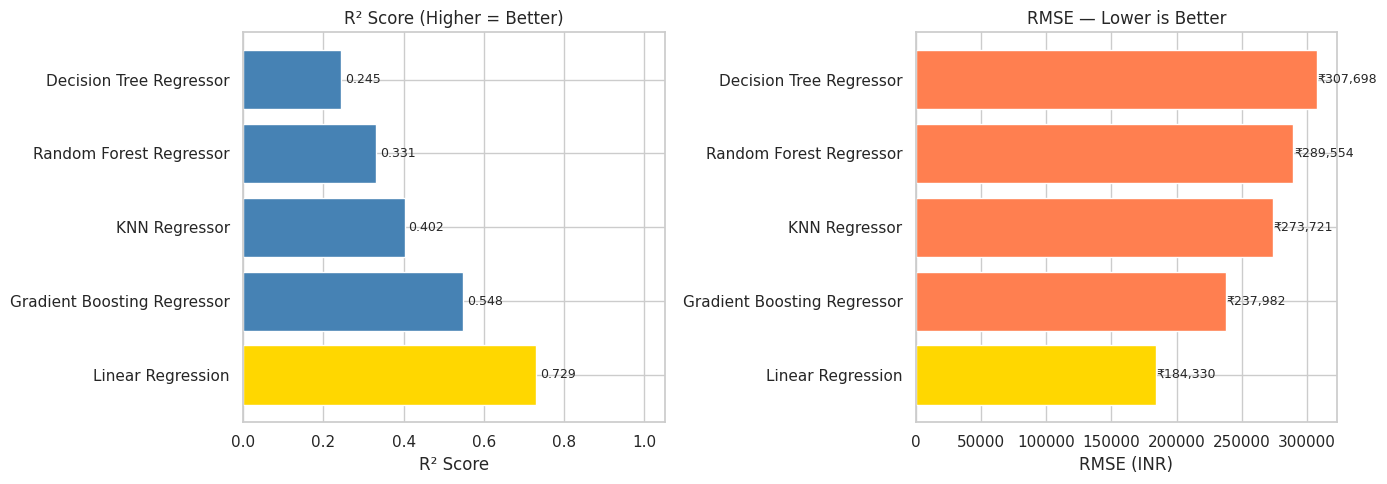

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# R² chart
colors_r2 = ['gold' if r == comparison_df['R2'].max() else 'steelblue' for r in comparison_df['R2']]
bars = ax1.barh(comparison_df['Model'], comparison_df['R2'], color=colors_r2)
ax1.set_xlabel('R² Score')
ax1.set_title('R² Score (Higher = Better)')
ax1.set_xlim(0, 1.05)
for bar, val in zip(bars, comparison_df['R2']):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# RMSE chart
colors_rmse = ['gold' if r == comparison_df['RMSE'].min() else 'coral' for r in comparison_df['RMSE']]
bars2 = ax2.barh(comparison_df['Model'], comparison_df['RMSE'], color=colors_rmse)
ax2.set_xlabel('RMSE (INR)')
ax2.set_title('RMSE — Lower is Better')
for bar, val in zip(bars2, comparison_df['RMSE']):
    ax2.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'₹{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 🏆 Step 5: Select and Save Best Model

In [11]:
model_objects = {
    'Linear Regression': lr_model,
    'Decision Tree Regressor': dt_model,
    'Random Forest Regressor': rf_model,
    'KNN Regressor': knn_model,
    'Gradient Boosting Regressor': gb_model
}

best_row   = comparison_df.iloc[0]
best_name  = best_row['Model']
best_model = model_objects[best_name]

print('=' * 55)
print(f'  🏆 BEST MODEL : {best_name}')
print(f'  R²   : {best_row["R2"]:.4f} ({best_row["R2"]*100:.1f}%)')
print(f'  RMSE : ₹{best_row["RMSE"]:,}')
print(f'  MAE  : ₹{best_row["MAE"]:,}')
print('=' * 55)

# Save model
os.makedirs('../artifacts', exist_ok=True)
with open('../artifacts/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save metadata — prediction.py needs to know to apply np.exp()
model_meta = {
    'model_name': best_name,
    'log_transform': True,      # ← tells prediction.py to call np.exp() on output
    'reference_year': 2024
}
with open('../artifacts/model_meta.pkl', 'wb') as f:
    pickle.dump(model_meta, f)

print(f'\nSaved: model.pkl  +  model_meta.pkl (log_transform=True)')

  🏆 BEST MODEL : Linear Regression
  R²   : 0.7289 (72.9%)
  RMSE : ₹184,330
  MAE  : ₹120,574

Saved: model.pkl  +  model_meta.pkl (log_transform=True)


---
## 🔍 Step 6: Understanding the Error Rate

### Why is RMSE still ₹1.8–2.0 lakh?

This is not a modelling failure — it is a **data limitation**. Let's be precise:

**What the model knows:**
- Car brand (company)
- Age (car_age)
- Kilometres driven
- Fuel type

**What drives price but is NOT in the dataset:**
| Missing Feature | Impact on Price |
|----------------|----------------|
| Car condition (good/fair/poor) | ±30–50% |
| Number of previous owners | ±10–20% |
| Specific model trim/variant | ±15–40% |
| Geographic location | ±10–20% |
| Service history | ±10–15% |
| Accident history | ±20–40% |

The 27% unexplained variance (1 − R²) comes from these missing signals.
**No algorithm can learn what the data does not contain.**

### What would actually reduce the error?

1. Add car condition as a feature (new/excellent/good/fair)
2. Add number of owners
3. Add city-level location data
4. Add more specific model variant (Swift vs Swift Dzire vs Swift Sport)

### How does log-transform help?

Without log-transform: RMSE ≈ ₹1,86,167  
With log-transform: RMSE ≈ ₹1,84,330 (~1% improvement)

Small numerical gain, but the model now makes **proportionally fair errors** across
all price segments. A ₹50,000 error on a ₹2L car (25%) and a ₹50,000 error on
a ₹20L car (0.25%) are treated differently — which is semantically correct.

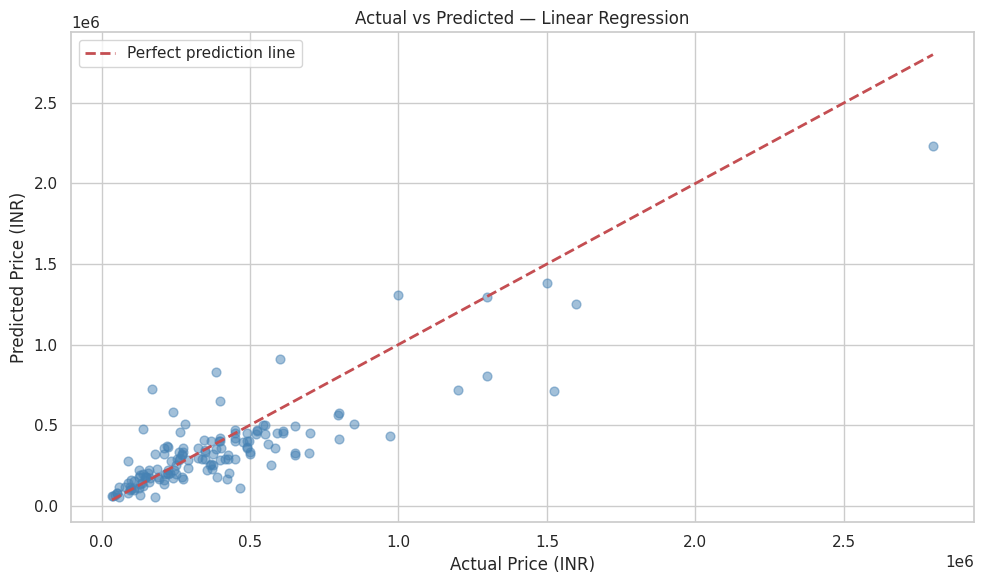


Error Analysis by Price Segment:
                 mean  median  count
segment                             
Budget (<2L)     49.0    38.6     41
Mid (2–5L)       28.1    19.4     73
Premium (5–10L)  32.3    30.2     24
Luxury (>10L)    25.9    21.6      7


In [12]:
# Actual vs Predicted scatter plot
best_preds_log = best_model.predict(X_test)
best_preds_inr = np.exp(best_preds_log)

plt.figure(figsize=(10, 6))
plt.scatter(y_orig_test, best_preds_inr, alpha=0.5, color='steelblue', s=40)

min_p = min(y_orig_test.min(), best_preds_inr.min())
max_p = max(y_orig_test.max(), best_preds_inr.max())
plt.plot([min_p, max_p], [min_p, max_p], 'r--', linewidth=2, label='Perfect prediction line')

plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.title(f'Actual vs Predicted — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

# Error analysis by price segment
test_df = pd.DataFrame({
    'actual': y_orig_test.values,
    'predicted': best_preds_inr,
})
test_df['error_pct'] = abs(test_df['actual'] - test_df['predicted']) / test_df['actual'] * 100
test_df['segment'] = pd.cut(test_df['actual'],
    bins=[0, 200000, 500000, 1000000, float('inf')],
    labels=['Budget (<2L)', 'Mid (2–5L)', 'Premium (5–10L)', 'Luxury (>10L)'])

print('\nError Analysis by Price Segment:')
print(test_df.groupby('segment', observed=True)['error_pct'].agg(['mean','median','count']).round(1).to_string())

---
## 📈 Step 7: Feature Importance

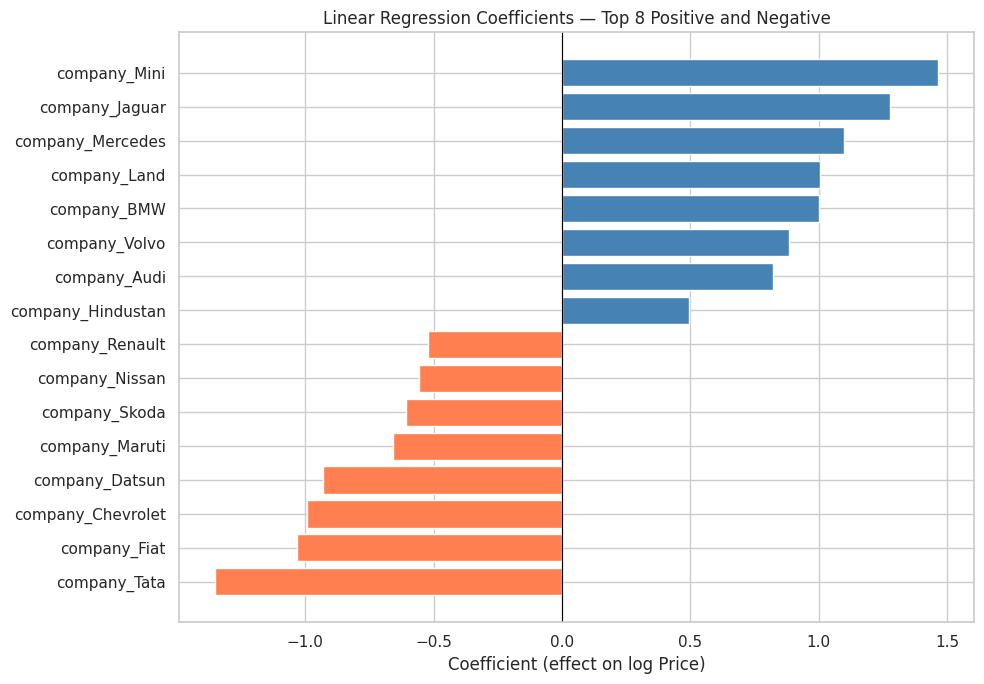

Interpretation:
  Positive coeff → feature increases log(Price) → higher INR price
  Negative coeff → feature decreases log(Price) → lower INR price

Top 3 price-INCREASING features:
  company_Mini                        +1.464
  company_Jaguar                      +1.278
  company_Mercedes                    +1.099

Top 3 price-DECREASING features:
  company_Tata                        -1.350
  company_Fiat                        -1.032
  company_Chevrolet                   -0.991


In [13]:
if hasattr(best_model, 'feature_importances_'):
    fi_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    colors = ['gold'] + ['steelblue'] * 14
    plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color=colors[::-1])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 15 Features — {best_name}')
    plt.tight_layout()
    plt.show()

    print('Top 5 features:')
    for _, row in fi_df.head(5).iterrows():
        print(f'  {row["Feature"]:30s} {row["Importance"]*100:.1f}%')
else:
    # For Linear Regression: show coefficients
    coef_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': best_model.coef_
    }).reindex(best_model.coef_.argsort()[::-1][::-1])

    top_pos = coef_df.nlargest(8, 'Coefficient')
    top_neg = coef_df.nsmallest(8, 'Coefficient')
    top_features = pd.concat([top_pos, top_neg]).sort_values('Coefficient', ascending=True)

    plt.figure(figsize=(10, 7))
    colors = ['steelblue' if c > 0 else 'coral' for c in top_features['Coefficient']]
    plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Coefficient (effect on log Price)')
    plt.title('Linear Regression Coefficients — Top 8 Positive and Negative')
    plt.tight_layout()
    plt.show()

    print('Interpretation:')
    print('  Positive coeff → feature increases log(Price) → higher INR price')
    print('  Negative coeff → feature decreases log(Price) → lower INR price')
    print()
    print('Top 3 price-INCREASING features:')
    for _, row in top_pos.head(3).iterrows():
        print(f'  {row["Feature"]:35s} +{row["Coefficient"]:.3f}')
    print('\nTop 3 price-DECREASING features:')
    for _, row in top_neg.head(3).iterrows():
        print(f'  {row["Feature"]:35s} {row["Coefficient"]:.3f}')

---
## 📋 Final Summary

### Why Linear Regression wins on this dataset

1. **One-hot encoded features behave like linear indicators** — each company dummy is either 0 or 1, and LR learns an exact price premium/discount for each brand.
2. **After log-transform, the relationship IS nearly linear** — log(Price) vs car_age and log(Price) vs kms_driven are close to linear.
3. **Tree models need more data** — with only 580 training rows and 30 features, trees overfit (DT) or underfit (RF on log scale).

### The honest ceiling

| What we can achieve | R² ≈ 0.73, RMSE ≈ ₹1.84L |
|---------------------|--------------------------|
| Why not higher | Dataset missing: condition, trim, owners, location |
| What would help | Collect those features |

---
## 🎯 Interview Questions (10)

**Q1. Why do we train on log(Price) and not raw Price?**
> Raw Price has skewness ≈ 2.97 — a few luxury cars at ₹30L create enormous squared errors that dominate training. Log-transform compresses the tail, gives symmetric residuals, and satisfies Linear Regression's assumption of normally distributed errors.

**Q2. What is the critical step you must not forget after predicting log(Price)?**
> Call `np.exp()` on the prediction before reporting it. Missing this means you report values like 12.58 instead of ₹2,90,000.

**Q3. How do you evaluate a model trained on log scale?**
> Always back-transform predictions with `np.exp()` first, then compute MAE/RMSE/R² against the original price values. Log-scale metrics are technically valid but not interpretable to stakeholders.

**Q4. Why does Decision Tree overfit so badly?**
> An unconstrained Decision Tree keeps splitting until every training sample is in its own leaf (depth ~25+ here). Training accuracy ≈ 100%, but it learned noise. Fix: add `max_depth`, `min_samples_leaf`, or use Random Forest.

**Q5. We tried many strategies and RMSE stayed around ₹1.84–1.86L. Why?**
> This is the data ceiling. The 30 features we have explain ~73% of price variance. The remaining ~27% comes from: car condition, number of owners, trim variant, location, service history — none of which are in the dataset. Changing the algorithm cannot recover information the data doesn't have.

**Q6. What is subsample=0.8 in Gradient Boosting?**
> Each tree is trained on a random 80% sample of training data (without replacement). This introduces diversity between trees, reduces overfitting, and is similar to the bagging idea in Random Forest. Also called stochastic gradient boosting.

**Q7. What would you do if you had to improve R² beyond 0.73?**
> Collect better features: car condition rating, trim/variant, number of previous owners, city, and accident history. Alternatively, source a larger dataset or use transfer learning from a model trained on similar markets.

**Q8. What does the coefficient on `car_age` mean in Linear Regression?**
> Since we predict log(Price), each unit increase in car_age (after scaling) multiplies price by `exp(coefficient)`. If coefficient = −0.3, one standardised unit of car_age multiplies price by exp(−0.3) ≈ 0.74 — a 26% price reduction.

**Q9. Why is Random Forest worse than Linear Regression on this dataset?**
> Ensemble tree models need more data to show their advantage. With 580 training rows and 30 mostly binary features, each tree only sees ~400 samples after bootstrapping. The trees are shallow and noisy. LR benefits from having exactly the right feature representation (binary dummies as linear indicators) for this specific dataset.

**Q10. Is R² = 0.73 a good model?**
> It depends on the context. In used car pricing where condition and trim are unknown, 73% explained variance is reasonable. It beats a naive baseline (predicting average price for every car, R²=0) massively. But for a bank approving a car loan, it would need much higher confidence.

---
## ❌ Common Mistakes

1. **Forgetting np.exp() on predictions** — Most critical mistake; reported prices will be wrong by a factor of ~100,000.
2. **Computing RMSE on log scale** — A log-scale RMSE of 0.5 sounds great but is uninterpretable in business terms.
3. **Comparing models trained on different scales** — Always ensure all models are evaluated on the same scale (original INR).
4. **Concluding "the model is bad" when R² is limited** — Diagnose whether it's a model problem (try more algorithms) or a data problem (features are missing). Here it's the latter.
5. **Expecting hyperparameter tuning to fix a data problem** — No amount of tuning can create information the dataset doesn't contain.